# FL-эксперимент с CIFAR-100

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

In [3]:
def plot_acc_loss(acc, loss, rounds, distribution, sharing=False):
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 2, 1)
    plt.title("Accuracy")
    plt.xlabel("Раунд обучения")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.plot(rounds, acc)
    
    plt.subplot(1, 2, 2)
    plt.title("Loss")
    plt.xlabel("Раунд обучения")
    plt.ylabel("Loss")
    plt.grid()
    plt.plot(rounds, loss)
    
    title = f'FL с рабиением данных: {distribution}'
    if sharing:
        title = f'FL с рабиением данных: {distribution}\nИспользован подход data sharing'
    plt.suptitle(title)
    plt.show()

In [4]:
ROUNDS = [i for i in range(1, 101)]

## Без общей части датасета

In [5]:
with open('../metrics/history_iid_0.pkl', 'rb') as f:
    history_iid_0 = pickle.load(f)

with open('../metrics/history_quantity_skew_0.pkl', 'rb') as f:
    history_qs_0 = pickle.load(f)

with open('../metrics/history_dirichlet_0.pkl', 'rb') as f:
    history_dirichlet_0 = pickle.load(f)

with open('../metrics/history_pathological_0.pkl', 'rb') as f:
    history_pathological_0 = pickle.load(f)

In [7]:
with open('../metrics/history_iid_0.1.pkl', 'rb') as f:
    history_iid_ds = pickle.load(f)

with open('../metrics/history_quantity_skew_0.1.pkl', 'rb') as f:
    history_qs_ds = pickle.load(f)

with open('../metrics/history_dirichlet_0.1.pkl', 'rb') as f:
    history_dirichlet_ds = pickle.load(f)

with open('../metrics/history_pathological_0.1.pkl', 'rb') as f:
    history_pathological_ds = pickle.load(f)

### IID

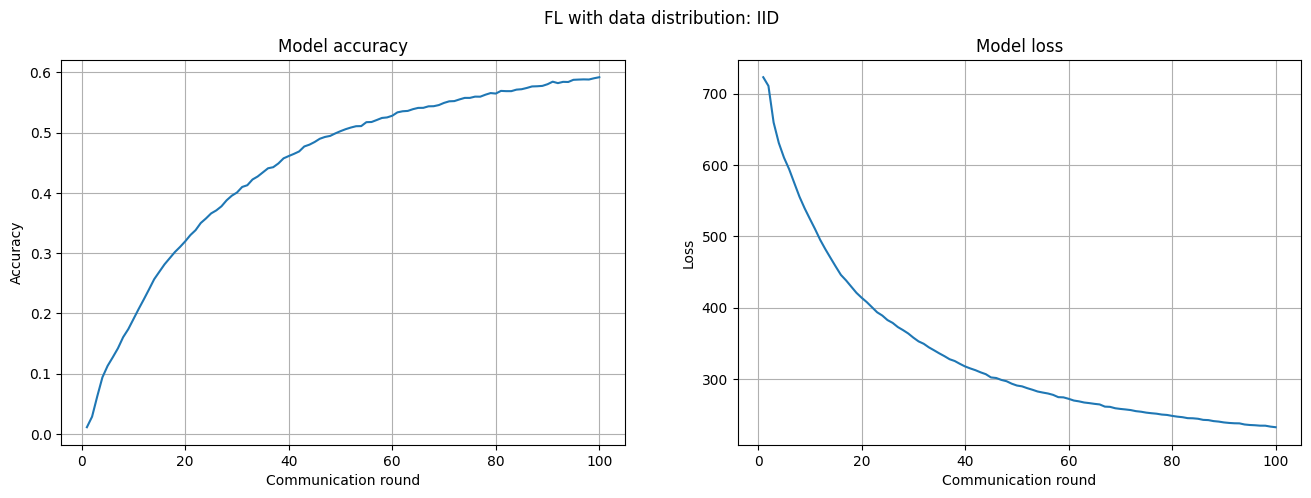

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_iid_0.metrics_distributed['accuracy']],
    [l[1] for l in history_iid_0.losses_distributed],
    ROUNDS,
    'IID'
)

### Quantity skew

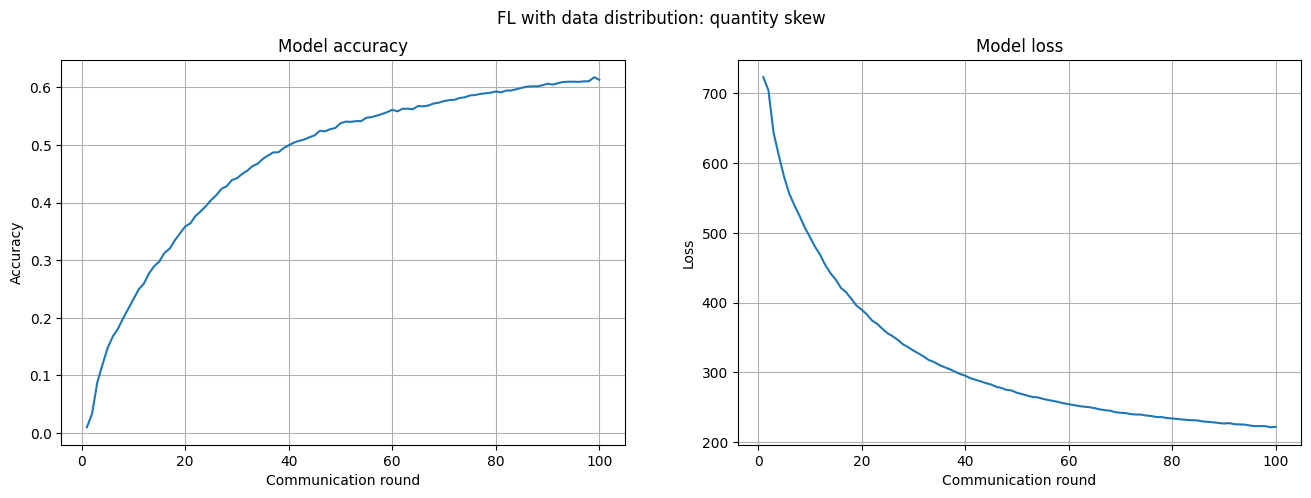

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_qs_0.metrics_distributed['accuracy']],
    [l[1] for l in history_qs_0.losses_distributed],
    ROUNDS,
    'quantity skew'
)

### Dirichlet

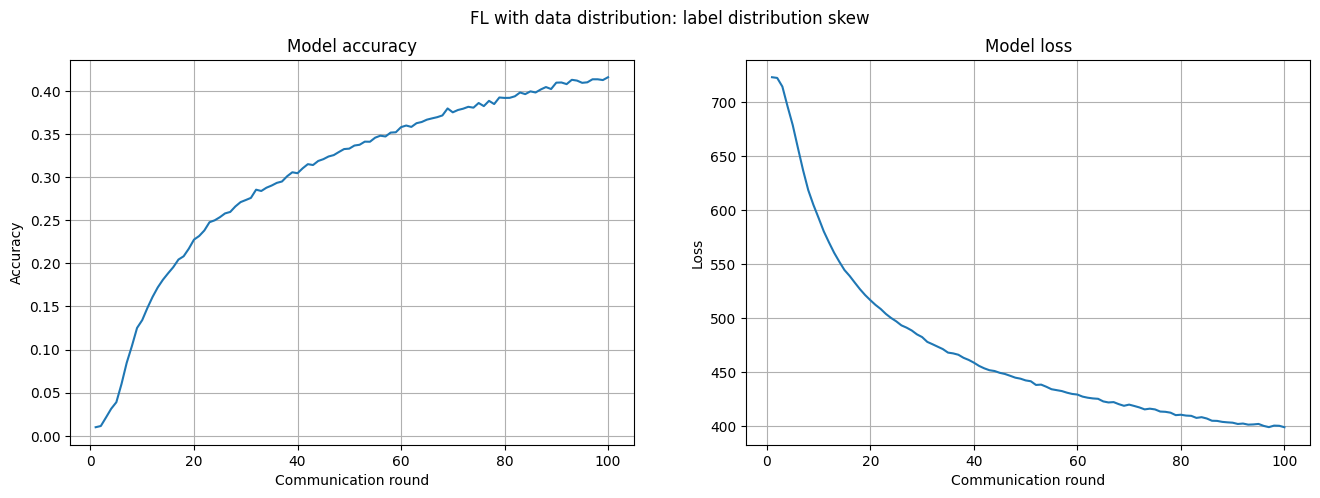

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_dirichlet_0.metrics_distributed['accuracy']],
    [l[1] for l in history_dirichlet_0.losses_distributed],
    ROUNDS,
    'label distribution skew'
)

### Non-IID

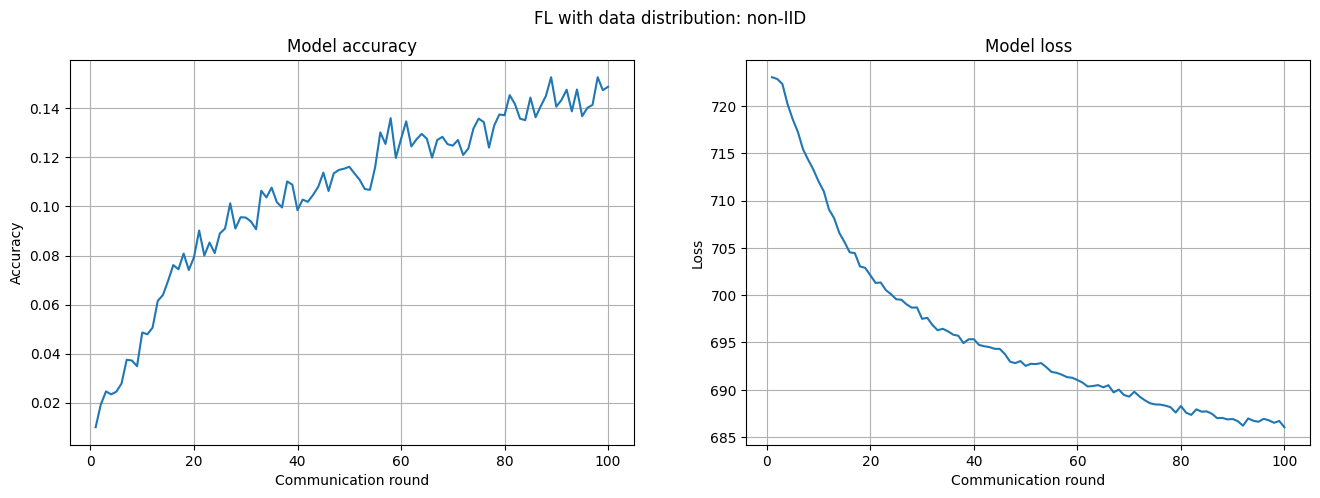

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_pathological_0.metrics_distributed['accuracy']],
    [l[1] for l in history_pathological_0.losses_distributed],
    ROUNDS,
    'non-IID'
)

## С общим датасетом

### IID

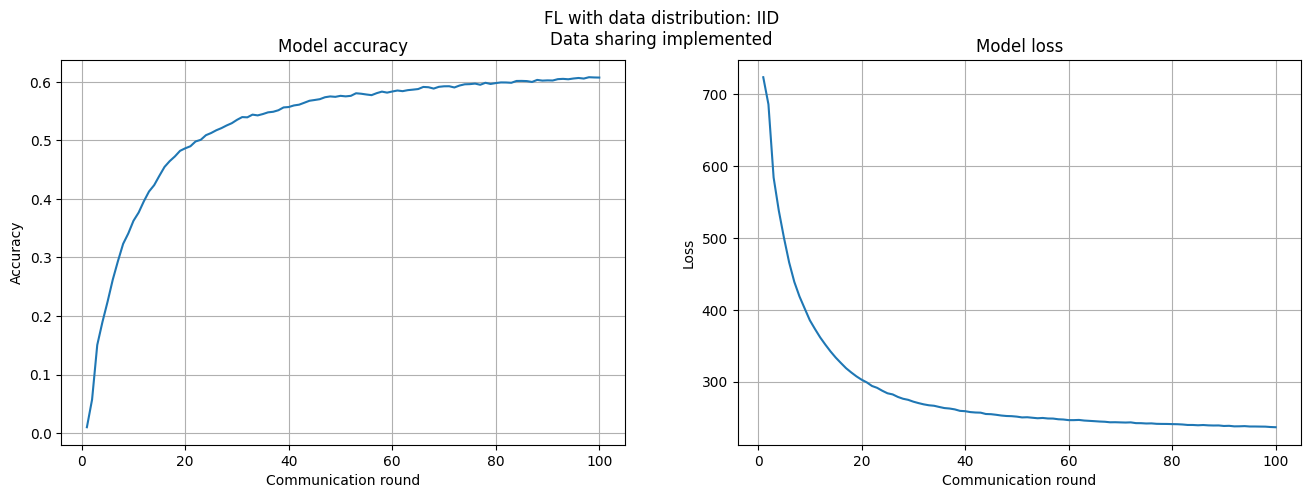

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_iid_ds.metrics_distributed['accuracy']],
    [l[1] for l in history_iid_ds.losses_distributed],
    ROUNDS,
    'IID',
    True
)

### Quantity skew

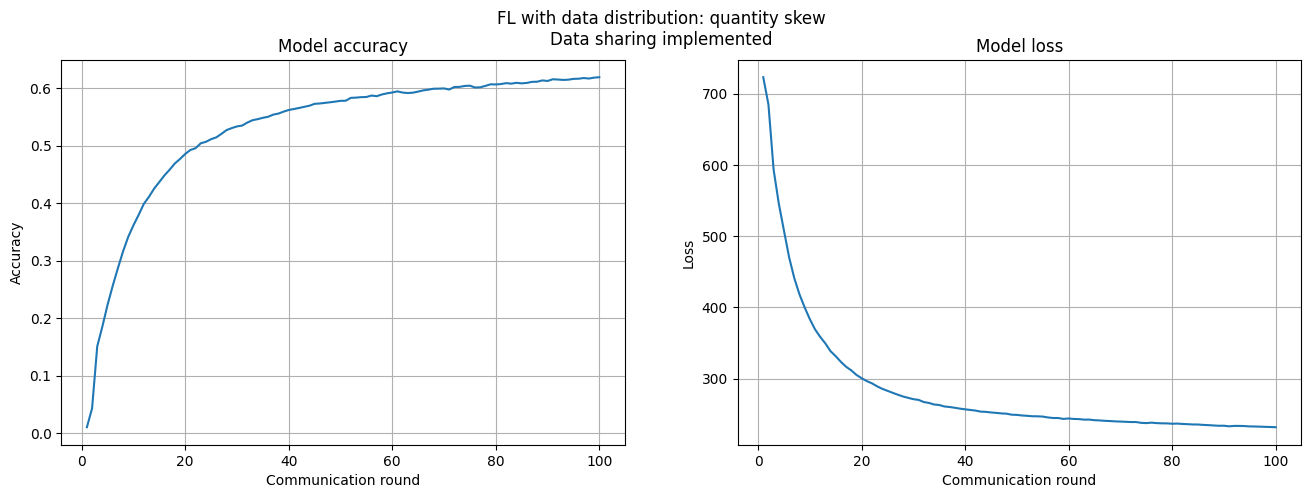

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_qs_ds.metrics_distributed['accuracy']],
    [l[1] for l in history_qs_ds.losses_distributed],
    ROUNDS,
    'quantity skew',
    True
)

### Dirichlet

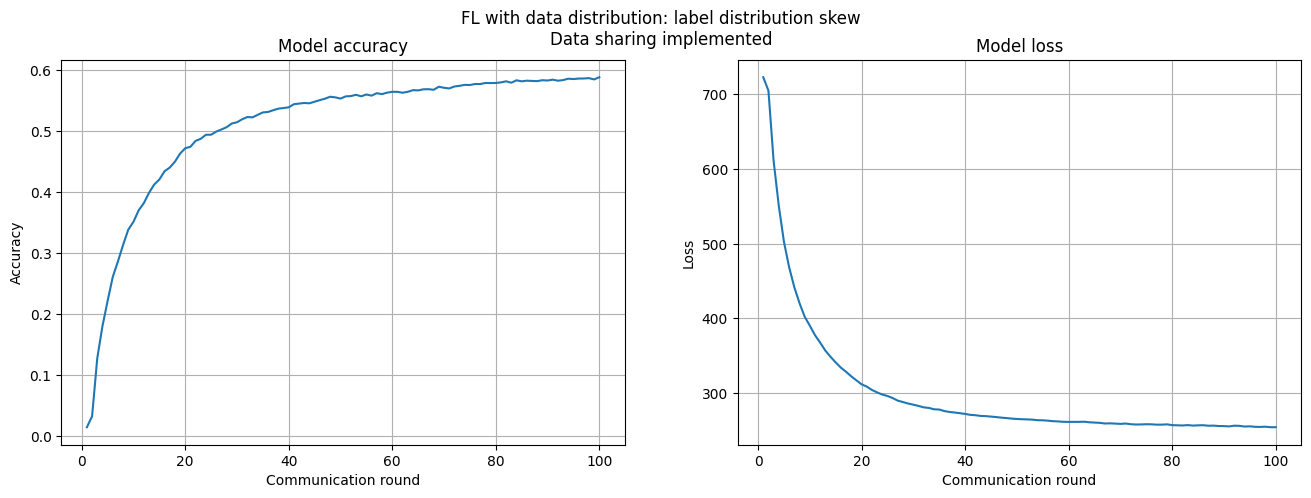

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_dirichlet_ds.metrics_distributed['accuracy']],
    [l[1] for l in history_dirichlet_ds.losses_distributed],
    ROUNDS,
    'label distribution skew',
    True
)

### Non-IID

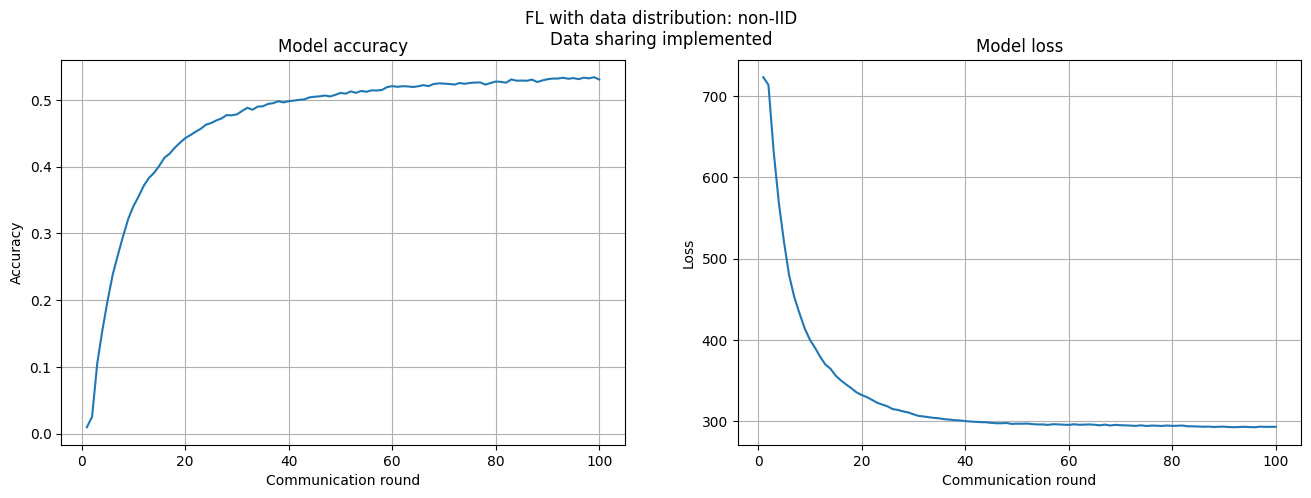

In [ ]:
plot_acc_loss(
    [acc[1] for acc in history_pathological_ds.metrics_distributed['accuracy']],
    [l[1] for l in history_pathological_ds.losses_distributed],
    ROUNDS,
    'non-IID',
    True
)

# Общие графики сравнения

In [1]:
def plot_acc_loss_all(acc_0, acc_ds, loss_0, loss_ds, rounds, distribution, metric='Accuracy'):
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"{metric}")
    plt.xlabel("Раунд обучения")
    plt.ylabel(f"{metric}")
    plt.grid()
    plt.plot(rounds, acc_0, c='0.6', label='Без data sharing')
    plt.plot(rounds, acc_ds, c='0', label='С использованием data sharing')
    
    plt.subplot(1, 2, 2)
    plt.title("Loss")
    plt.xlabel("Раунд обучения")
    plt.ylabel("Loss")
    plt.grid()
    plt.plot(rounds, loss_0, c='0.6', label='Без data sharing')
    plt.plot(rounds, loss_ds, c='0', label='С использованием data sharing')
    
    title = f'FL с разбиением данных: {distribution}'
    plt.suptitle(title)
    plt.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.3))
    plt.show()

## Non-IID

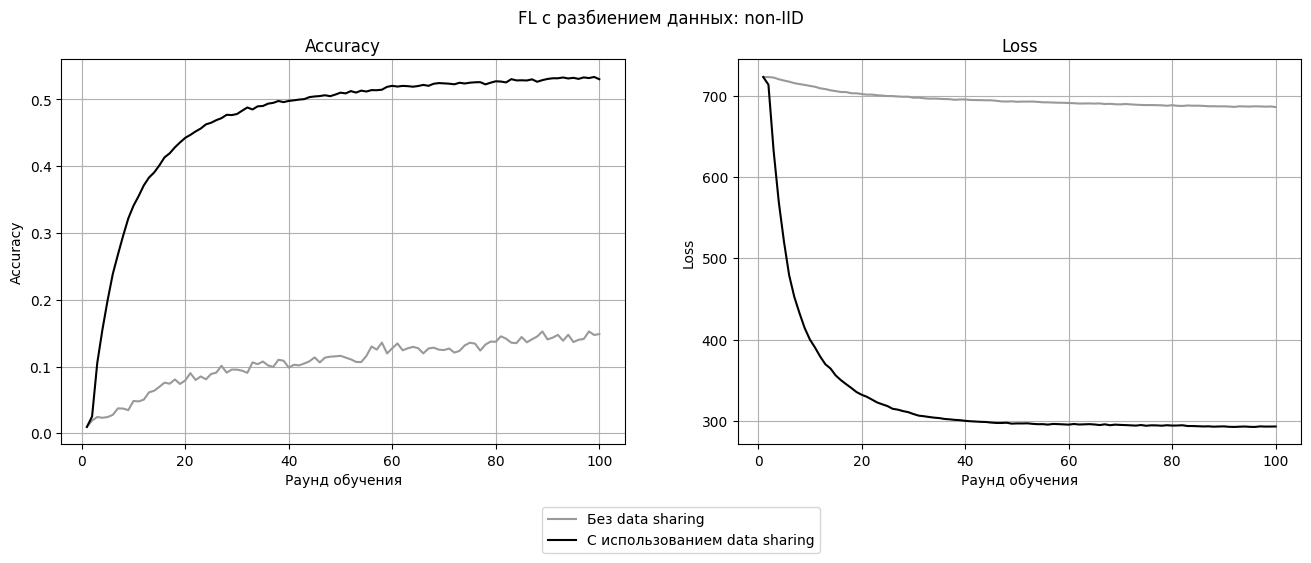

In [ ]:
plot_acc_loss_all(
    [acc[1] for acc in history_pathological_0.metrics_distributed['accuracy']],
    [acc[1] for acc in history_pathological_ds.metrics_distributed['accuracy']],
    [l[1] for l in history_pathological_0.losses_distributed],
    [l[1] for l in history_pathological_ds.losses_distributed],
    ROUNDS,
    'non-IID',
)

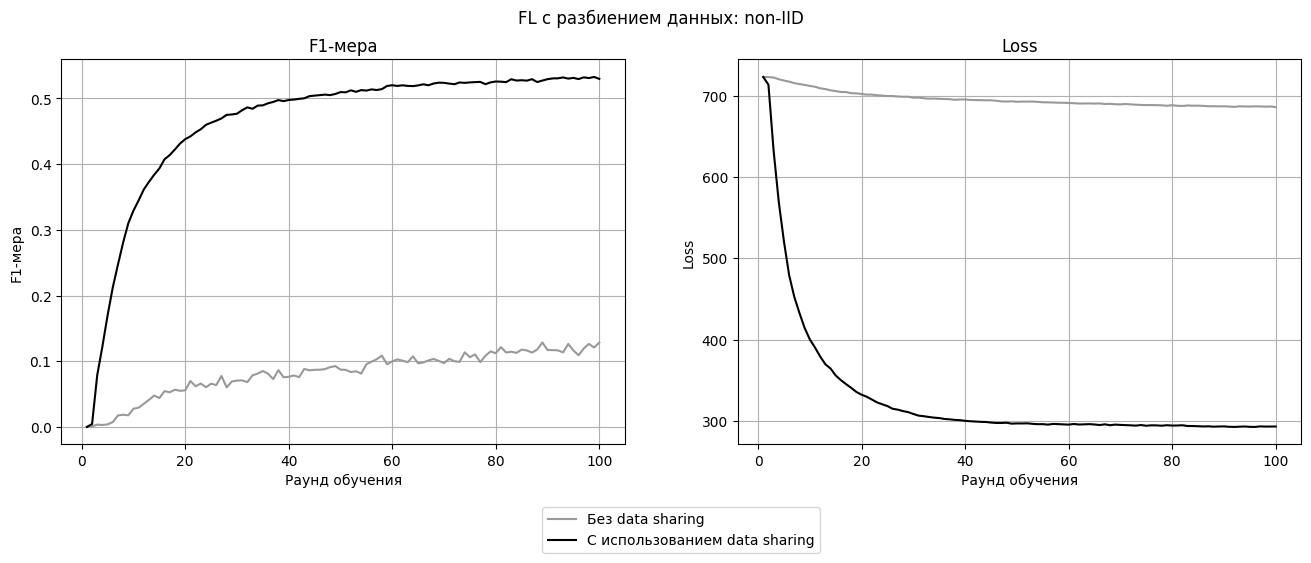

In [9]:
plot_acc_loss_all(
    [acc[1] for acc in history_pathological_0.metrics_distributed['f1']],
    [acc[1] for acc in history_pathological_ds.metrics_distributed['f1']],
    [l[1] for l in history_pathological_0.losses_distributed],
    [l[1] for l in history_pathological_ds.losses_distributed],
    ROUNDS,
    'non-IID',
    'F1-мера'
)

## Quantity skew

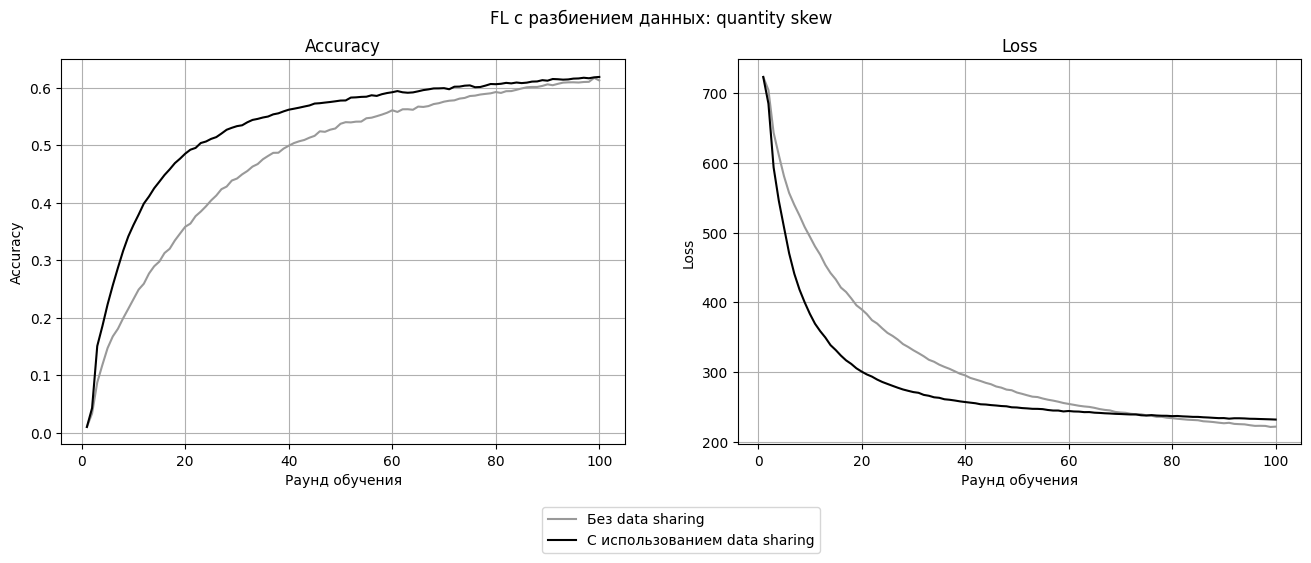

In [11]:
plot_acc_loss_all(
    [acc[1] for acc in history_qs_0.metrics_distributed['accuracy']],
    [acc[1] for acc in history_qs_ds.metrics_distributed['accuracy']],
    [l[1] for l in history_qs_0.losses_distributed],
    [l[1] for l in history_qs_ds.losses_distributed],
    ROUNDS,
    'quantity skew',
)

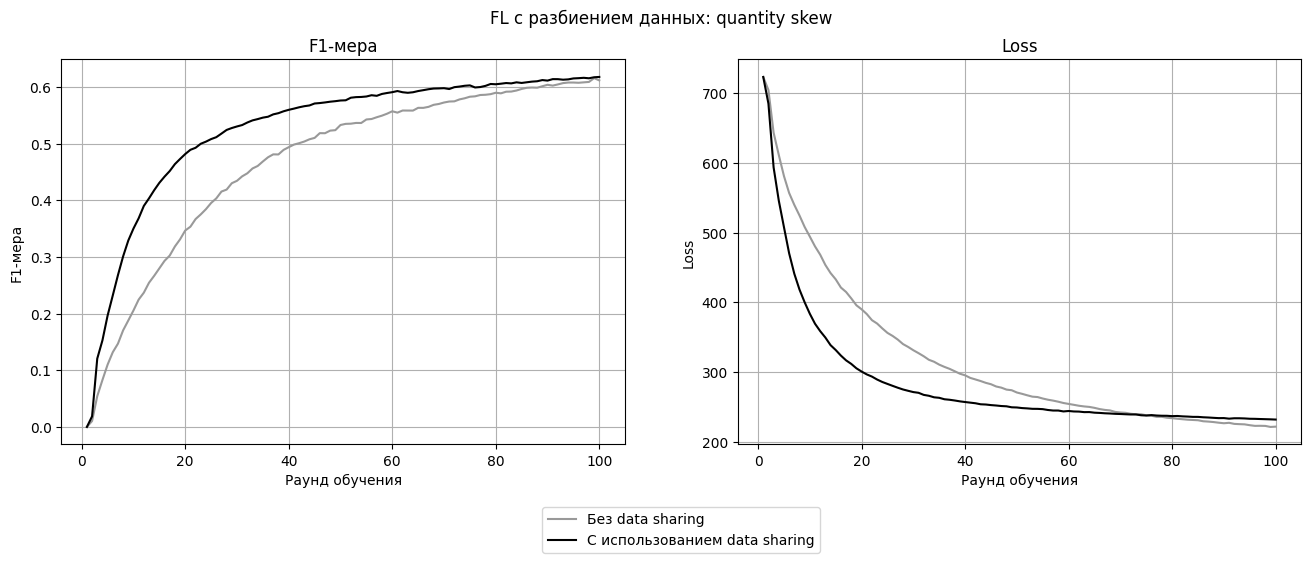

In [12]:
plot_acc_loss_all(
    [acc[1] for acc in history_qs_0.metrics_distributed['f1']],
    [acc[1] for acc in history_qs_ds.metrics_distributed['f1']],
    [l[1] for l in history_qs_0.losses_distributed],
    [l[1] for l in history_qs_ds.losses_distributed],
    ROUNDS,
    'quantity skew',
    'F1-мера'
)